In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-01-17 11:10:31.902928: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-17 11:10:31.930988: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-17 11:10:31.931012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-17 11:10:31.931890: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-17 11:10:31.937562: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [3]:
import sys
sys.path.append('../tools_')

from tools import *





In [6]:
"""#1channel, Y, Y_model, egm_tensor, length_list, AF_models, all_model_names, transfer_matrices = load_data(
    directory = data_dir, 
    data_type='1channelTensor',
    n_classes=DataConfig.n_classes,
    subsampling=True,
    fs_sub=DataConfig.fs_sub,
    norm=False,
    SR=True, SNR=DataConfig.SNR,
    n_batch=TrainConfig_1.batch_size_1,
    sinusoid=sinusoids, 
    SNR_em_noise = SNR_em_noise,
    SNR_white_noise = SNR_em_noise, 
    patches_oclussion=patches_oclussion,
    unfold_code=unfold_code, 
    inference = False)

"""
model_name = 'RA_RAA_141230'
egms = load_egms(model_name)

transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

(2048, 2000)


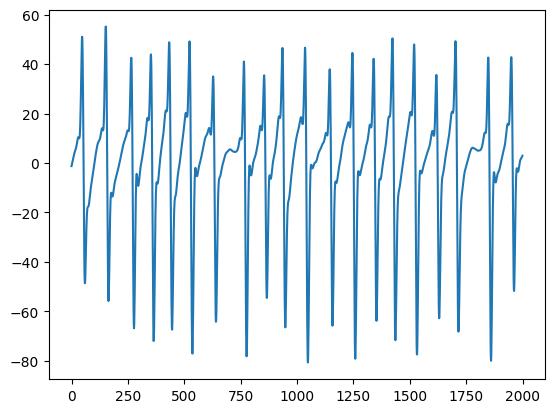

In [7]:
#egms

print(egms.shape)

plt.figure()

plt.plot(egms[10,:])

In [11]:
#matrices de transferencia

print(len(transfer_matrices))



10


In [20]:
#forward problem

#no me queda claro por qué hacemos el filtrado 
x = ECG_filtering(egms, 500)

print(x.shape)
A = transfer_matrices[0]

print(A[1].shape)

y = forward_problem(egms, A[0])
y_f = forward_problem(x,A[0])

(2048, 2000)
(64, 1)


(3610, 2000)


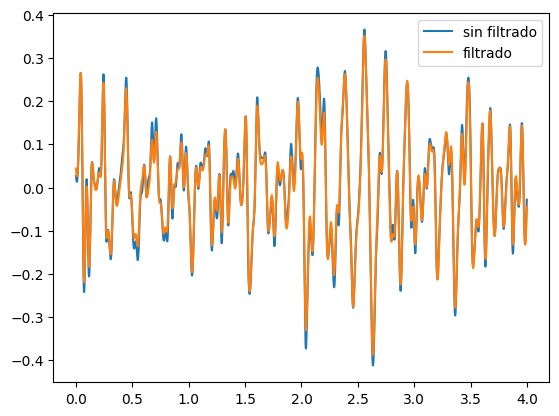

In [28]:
plt.figure()

print(y.shape)
t = np.arange(len(y[0,:]))/500
plt.plot(t,y[0,:],label='sin filtrado')
plt.plot(t,y_f[0,:],label='filtrado')

plt.legend()



In [32]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64 = y[A[1].ravel(),:]

print(bsps_64.shape)

(64, 2000)
